# MergeDNA Pre-training

This notebook demonstrates pre-training the MergeDNA model for genomic sequence modeling.

**Paper**: [MergeDNA: Context-aware Genome Modeling with Dynamic Tokenization through Token Merging](https://arxiv.org/abs/2511.14806)

**Pre-training Objectives**:
1. **MTR (Merged Token Reconstruction)**: Reconstruct original DNA from merged tokens
2. **Latent MTR**: Adaptive global token selection with compression
3. **AMTM (Adaptive Masked Token Modeling)**: Focus on high-information regions

## Setup and Imports

In [1]:
import sys
sys.path.insert(0, "..")

import os
import torch
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import numpy as np

# Import from mergedna package
from mergedna import (
    MergeDNAModel,
    LocalEncoder,
    LocalDecoder,
    DNADataset,
    load_sequences,
    merge_sequences,
    create_dataloader,
    sequence_to_tensor,
    tensor_to_sequence,
)

# Check device
device = torch.device(
    "cuda" if torch.cuda.is_available() 
    else "mps" if torch.backends.mps.is_available() 
    else "cpu"
)
print(f"Using device: {device}")

Using device: mps


/Users/sanjukta/probable-adventure/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [ ]:
# Paths
DATA_DIR = "../data/human_nontata_promoters/"
CHECKPOINT_DIR = "../checkpoints"
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "mergedna_pretrain.pt")

# Create checkpoint directory
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Model hyperparameters
DIM = 64  # Model dimension (increase for better performance)
LATENT_ENC_DEPTH = 2  # Latent encoder transformer layers
LATENT_DEC_DEPTH = 2  # Latent decoder transformer layers
MERGE_RATIO = 0.5  # Target ratio of tokens to keep

# Training hyperparameters
BATCH_SIZE = 4
LEARNING_RATE = 0.001
EPOCHS = 10 
LAMBDA_LATENT = 0.25  # Weight for Latent MTR loss
WEIGHT_DECAY = 0.01

## Data Loading

In [3]:
# Load sequences
sequences_dict = load_sequences(DATA_DIR)
#sequences = merge_sequences(sequences_dict)

sequences = merge_sequences(sequences_dict['train'])
test_sequences = merge_sequences(sequences_dict['test'])

print(f"Total sequences: {len(sequences)}")
print(f"Train positive: {len(sequences_dict['train']['positive'])}")
print(f"Train negative: {len(sequences_dict['train']['negative'])}")
print(f"\nExample sequence ({len(sequences[0])} bp):")
print(sequences[0][:80] + "...")

Total sequences: 27097
Train positive: 14742
Train negative: 12355

Example sequence (251 bp):
CAGGAATCGAACACTAGGAATCCTACTCGATAGGTGGCACGGATTGCGGAGAGAAACTTCGCGTGGGGGGGAACCCTAGG...


In [ ]:
print(f"Total sequences: {len(test_sequences)}")
print(f"Test positive: {len(sequences_dict['test']['positive'])}")
print(f"Test negative: {len(sequences_dict['test']['negative'])}")
print(f"\nExample sequence ({len(test_sequences[0])} bp):")
print(test_sequences[0])

Total sequences: 9034
Test positive: 4915
Test negative: 4119

Example sequence (251 bp):
AATTTGCCTGTCTTCTCTTTCCATCTTTGCAGCCCTCGTGCCTGTTCAATCAACAGTTCCCACTTGGGGTTGGGGAAGGT...


In [6]:
# Create DataLoader
train_loader = create_dataloader(
    sequences,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print(f"Number of batches: {len(train_loader)}")
print(f"Batch size: {BATCH_SIZE}")

Number of batches: 6775
Batch size: 4


## Model Initialization

In [11]:
# Initialize model components
local_encoder = LocalEncoder(
    dim=DIM,
    merge_ratio=MERGE_RATIO
).to(device)

local_decoder = LocalDecoder(dim=DIM).to(device)

# Create the full MergeDNA model
model = MergeDNAModel(
    local_encoder=local_encoder,
    local_decoder=local_decoder,
    dim=DIM,
    latent_enc_depth=LATENT_ENC_DEPTH,
    latent_dec_depth=LATENT_DEC_DEPTH,
    vocab_size=4
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 9,670
Trainable parameters: 9,670


## Training

In [12]:
def train_epoch(model, dataloader, optimizer, device, lambda_latent=0.25):
    """Train for one epoch."""
    model.train()
    
    epoch_losses = {'total': [], 'mtr': [], 'latent': [], 'amtm': []}
    
    pbar = tqdm(dataloader, desc="Training")
    for batch_idx, batch in enumerate(pbar):
        batch = batch.to(device)
        optimizer.zero_grad()
        
        try:
            loss, logs = model.forward_train(batch, lambda_latent=lambda_latent)
        except Exception as e:
            print(f"Error in batch {batch_idx}: {e}")
            continue
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_losses['total'].append(loss.item())
        epoch_losses['mtr'].append(logs['loss_mtr'])
        epoch_losses['latent'].append(logs['loss_latent'])
        epoch_losses['amtm'].append(logs['loss_amtm'])
        
        pbar.set_postfix({
            'loss': f"{loss.item():.4f}",
            'mtr': f"{logs['loss_mtr']:.3f}",
            'amtm': f"{logs['loss_amtm']:.3f}"
        })
    
    return {k: np.mean(v) if v else 0.0 for k, v in epoch_losses.items()}

In [13]:
# Initialize optimizer and scheduler
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

# Training history
history = {'total': [], 'mtr': [], 'latent': [], 'amtm': [], 'lr': []}

print("Starting pre-training...")
print("=" * 60)

best_loss = float('inf')

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    
    epoch_losses = train_epoch(
        model, train_loader, optimizer, device,
        lambda_latent=LAMBDA_LATENT
    )
    
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    
    # Update history
    for key in ['total', 'mtr', 'latent', 'amtm']:
        history[key].append(epoch_losses[key])
    history['lr'].append(current_lr)
    
    print(
        f"  Total: {epoch_losses['total']:.4f} | "
        f"MTR: {epoch_losses['mtr']:.4f} | "
        f"Latent: {epoch_losses['latent']:.4f} | "
        f"AMTM: {epoch_losses['amtm']:.4f}"
    )
    
    # Save best model
    if epoch_losses['total'] < best_loss:
        best_loss = epoch_losses['total']
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': best_loss,
            'history': history,
            'config': {
                'dim': DIM,
                'latent_enc_depth': LATENT_ENC_DEPTH,
                'latent_dec_depth': LATENT_DEC_DEPTH,
                'merge_ratio': MERGE_RATIO
            }
        }, CHECKPOINT_PATH)
        print(f"  Saved best model (loss: {best_loss:.4f})")

print("\n" + "=" * 60)
print("Pre-training complete!")

Starting pre-training...

Epoch 1/1


Training: 100%|██████████| 6775/6775 [11:24<00:00,  9.89it/s, loss=1.4627, mtr=0.379, amtm=0.991]

  Total: 1.8190 | MTR: 0.4056 | Latent: 0.4057 | AMTM: 1.3120
  Saved best model (loss: 1.8190)

Pre-training complete!


## Training Visualization

Loaded history from checkpoint (epoch 1)


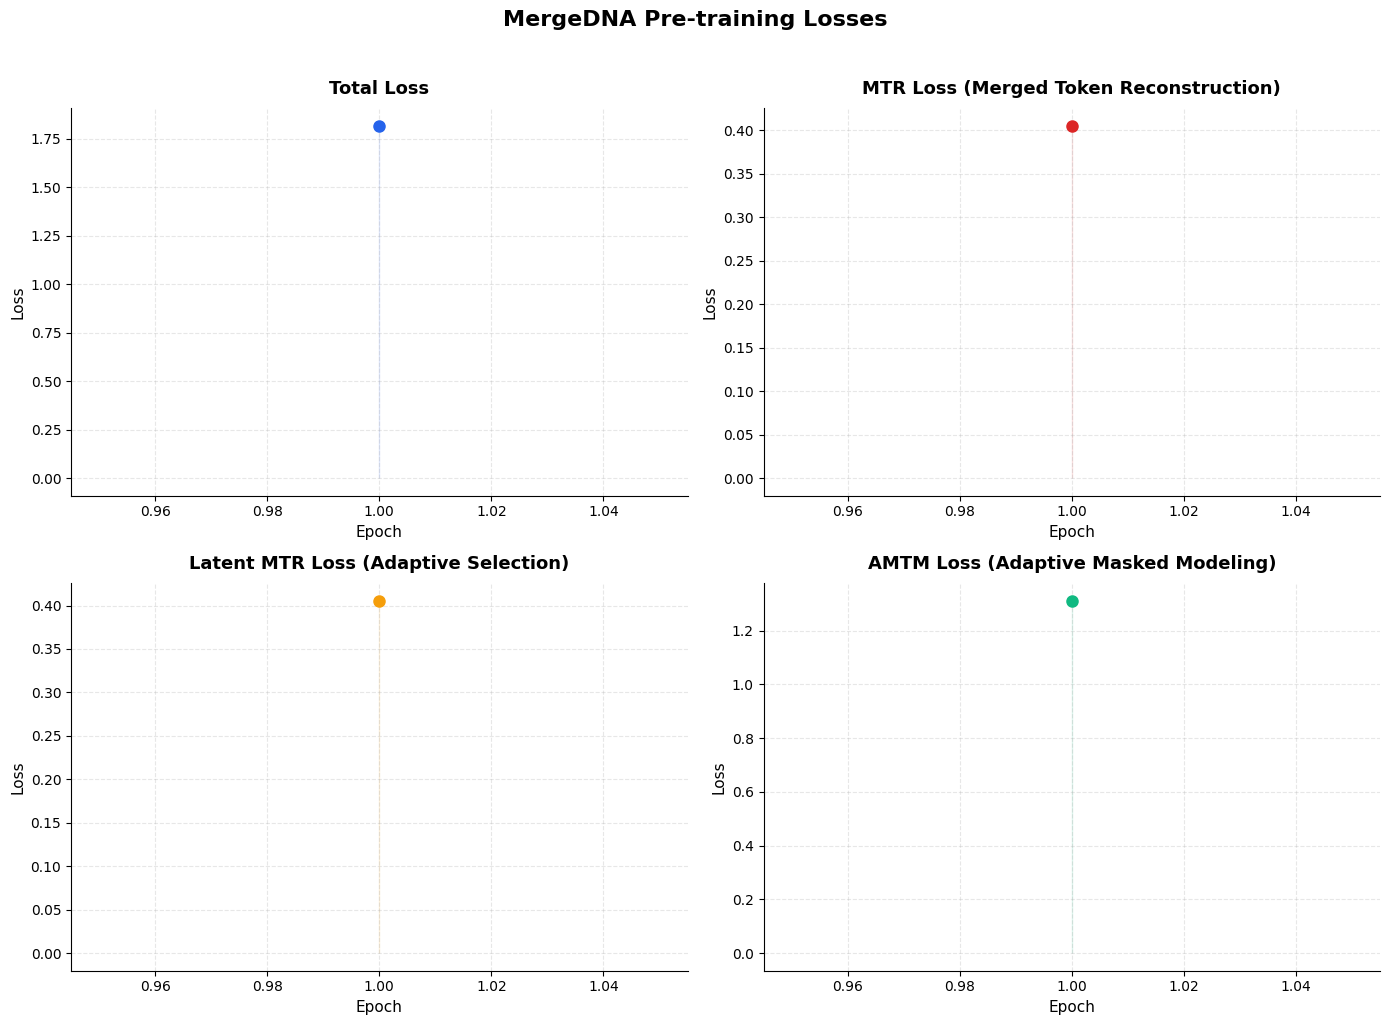


TRAINING SUMMARY

Final Losses (Epoch 1)
  Total:  1.8190
  MTR:    0.4056
  Latent: 0.4057
  AMTM:   1.3120


In [14]:
# Load history from checkpoint if needed
if os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
    if 'history' in checkpoint:
        history = checkpoint['history']
        print(f"Loaded history from checkpoint (epoch {checkpoint['epoch'] + 1})")

# Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('MergeDNA Pre-training Losses', fontsize=16, fontweight='bold', y=1.02)

colors = {
    'total': '#2563EB',
    'mtr': '#DC2626',
    'latent': '#F59E0B',
    'amtm': '#10B981'
}

epochs_range = range(1, len(history['total']) + 1)

for ax, (key, title) in zip(
    axes.flat,
    [('total', 'Total Loss'),
     ('mtr', 'MTR Loss (Merged Token Reconstruction)'),
     ('latent', 'Latent MTR Loss (Adaptive Selection)'),
     ('amtm', 'AMTM Loss (Adaptive Masked Modeling)')]
):
    ax.plot(epochs_range, history[key], 'o-', color=colors[key], linewidth=2.5, markersize=8)
    ax.fill_between(epochs_range, history[key], alpha=0.15, color=colors[key])
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Loss', fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print("\n" + "=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)
print(f"\nFinal Losses (Epoch {len(history['total'])})")
print(f"  Total:  {history['total'][-1]:.4f}")
print(f"  MTR:    {history['mtr'][-1]:.4f}")
print(f"  Latent: {history['latent'][-1]:.4f}")
print(f"  AMTM:   {history['amtm'][-1]:.4f}")

if len(history['total']) > 1:
    improvement = (history['total'][0] - history['total'][-1]) / history['total'][0] * 100
    print(f"\nImprovement: {improvement:.1f}% reduction in total loss")

## Inference: Reconstruction

In [15]:
def load_model_from_checkpoint(checkpoint_path, device):
    """Load pre-trained model from checkpoint."""
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    # Get config from checkpoint or use defaults
    config = checkpoint.get('config', {})
    dim = config.get('dim', DIM)
    merge_ratio = config.get('merge_ratio', MERGE_RATIO)
    latent_enc_depth = config.get('latent_enc_depth', LATENT_ENC_DEPTH)
    latent_dec_depth = config.get('latent_dec_depth', LATENT_DEC_DEPTH)
    
    # Recreate model
    local_encoder = LocalEncoder(dim=dim, merge_ratio=merge_ratio).to(device)
    local_decoder = LocalDecoder(dim=dim).to(device)
    
    model = MergeDNAModel(
        local_encoder=local_encoder,
        local_decoder=local_decoder,
        dim=dim,
        latent_enc_depth=latent_enc_depth,
        latent_dec_depth=latent_dec_depth,
        vocab_size=4
    ).to(device)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    print(f"Loaded model from epoch {checkpoint['epoch'] + 1}")
    print(f"Training loss: {checkpoint['loss']:.4f}")
    
    return model

# Load the model
inference_model = load_model_from_checkpoint(CHECKPOINT_PATH, device)

Loaded model from epoch 1
Training loss: 1.8190


In [16]:
@torch.no_grad()
def reconstruct_sequence(model, sequence, device):
    """Reconstruct a DNA sequence through the autoencoder."""
    model.eval()
    
    # Convert to tensor
    x = sequence_to_tensor(sequence).unsqueeze(0).to(device)
    
    # Forward pass
    logits, predictions, info = model(x)
    
    # Calculate reconstruction error
    loss = F.cross_entropy(logits.view(-1, 4), x.view(-1), reduction='none')
    per_position_error = loss.view(x.shape)
    
    # Get reconstructed sequence
    reconstructed = tensor_to_sequence(predictions[0])
    
    # Calculate accuracy
    accuracy = (predictions == x).float().mean().item()
    
    return {
        'original': sequence,
        'reconstructed': reconstructed,
        'accuracy': accuracy,
        'mean_error': per_position_error.mean().item(),
        'per_position_error': per_position_error[0].cpu().numpy(),
        'compression_ratio': info['compression_ratio']
    }

In [17]:
# Test reconstruction on a sequence
test_sequence = test_sequences[200]
result = reconstruct_sequence(inference_model, test_sequence, device)

print("=" * 70)
print("RECONSTRUCTION TEST")
print("=" * 70)
print(f"\nOriginal:      {result['original'][:60]}...")
print(f"Reconstructed: {result['reconstructed'][:60]}...")
print(f"\nAccuracy:      {result['accuracy'] * 100:.2f}%")
print(f"Mean Error:    {result['mean_error']:.4f}")
print(f"Compression:   {result['compression_ratio']:.2f}x")

# Count mismatches
mismatches = sum(1 for a, b in zip(result['original'], result['reconstructed']) if a != b)
print(f"Mismatches:    {mismatches}/{len(result['original'])} positions")

RECONSTRUCTION TEST

Original:      CAAGATAAAATTAACTACTTCTCTGTGAATGGATCATGAAATATTCTCTTAATGGAATAT...
Reconstructed: TAAAATAAAATTAACTATTTCTCTGTGAATGAATCATAAAATATTTTTTTAATAGAATAT...

Accuracy:      86.85%
Mean Error:    0.3049
Compression:   0.50x
Mismatches:    33/251 positions


In [ ]:
# Plot per-position reconstruction error
plt.figure(figsize=(14, 4))
plt.bar(range(len(result['per_position_error'])), result['per_position_error'], width=1.0, alpha=0.7)
plt.xlabel('Position')
plt.ylabel('Reconstruction Error (Cross-Entropy)')
plt.title('Per-Position Reconstruction Error')
plt.axhline(y=result['mean_error'], color='r', linestyle='--', label=f"Mean: {result['mean_error']:.4f}")
plt.legend()
plt.tight_layout()
plt.show()